In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv('1980sClassics.csv')

In [3]:
df.head(6)

,Track,Artist,Duration,Time_Signature,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Popularity,Year
0,Babe,Styx,3:38,4,0.700,0.582,11,-5.960,0,0.0356,0.05020,0.000000,0.0881,0.785,116.712,96,1980
1,The Rose,Bette Midler,4:04,4,0.264,0.640,8,-6.221,1,0.0442,0.03930,0.000002,0.1510,0.190,84.828,92,1980
2,Cars,Gary Numan,4:08,4,0.338,0.562,9,-7.181,1,0.0290,0.03900,0.000000,0.1070,0.259,149.907,82,1980
3,Magic,Olivia Newton-John,2:17,4,0.911,0.689,1,-6.176,1,0.2650,0.00119,0.000000,0.0704,0.546,140.034,80,1980
4,We Don’t Talk Anymore,Cliff Richard,3:37,4,0.728,0.563,1,-8.053,0,0.1340,0.62100,0.000000,0.1790,0.352,100.017,80,1980
5,Desire,Andy Gibb,2:59,4,0.587,0.924,11,-5.433,0,0.0457,0.03110,0.017100,0.2300,0.509,140.009,79,1980


In [4]:
df.isnull().sum()

Track               0
Artist              0
Duration            0
Time_Signature      0
Danceability        0
Energy              0
Key                 0
Loudness            0
Mode                0
Speechiness         0
Acousticness        0
Instrumentalness    0
Liveness            0
Valence             0
Tempo               0
Popularity          0
Year                0
dtype: int64

In [5]:
df.describe()

,Time_Signature,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Popularity,Year
count,998.000000,998.000000,998.000000,998.000000,998.000000,998.000000,998.00000,998.000000,998.000000,998.000000,998.000000,998.000000,998.000000,998.000000
mean,3.966934,0.626469,0.633362,5.225451,-8.886123,0.689379,0.05763,0.244627,0.042554,0.178618,0.603099,120.904174,57.743487,1984.498998
std,0.228178,0.151517,0.203787,3.657376,3.829896,0.462980,0.05574,0.248634,0.157057,0.162648,0.257874,26.254971,17.397193,2.873372
min,1.000000,0.174000,0.018300,0.000000,-28.980000,0.000000,0.02270,0.000003,0.000000,0.022300,0.028700,61.530000,0.000000,1980.000000
25%,4.000000,0.534000,0.489000,2.000000,-11.256000,0.000000,0.03170,0.043350,0.000000,0.083950,0.388000,102.303000,49.000000,1982.000000
50%,4.000000,0.633000,0.651500,5.000000,-8.270000,1.000000,0.03935,0.155000,0.000022,0.113500,0.644000,119.969000,60.000000,1984.500000
75%,4.000000,0.735000,0.797000,9.000000,-6.045000,1.000000,0.05645,0.387250,0.001448,0.225750,0.824750,135.000750,70.000000,1987.000000
max,5.000000,0.988000,0.994000,11.000000,-1.496000,1.000000,0.52400,0.996000,0.974000,0.981000,0.984000,208.571000,96.000000,1989.000000


In [7]:
df.Artist.value_counts()

Artist
Madonna                        17
Michael Jackson                13
Daryl Hall & John Oates        13
Lionel Richie                  12
Prince                         11
                               ..
Annie Lennox & Al Green         1
Babyface                        1
Ann Wilson and Robin Zander     1
Boys Club                       1
Will to Power                   1
Name: count, Length: 475, dtype: int64

In [6]:
df.Artist.unique()

<ArrowStringArray>
[                       'Styx',                'Bette Midler',
                  'Gary Numan',          'Olivia Newton-John',
               'Cliff Richard',                   'Andy Gibb',
             'Doobie Brothers',             'Michael Jackson',
               'Fleetwood Mac',                  'Diana Ross',
 ...
                  'Deon Estus',                'Soul II Soul',
                     'Surface',              'Gloria Estefan',
                     'Sa-Fire',     'Annie Lennox & Al Green',
                    'Babyface', 'Ann Wilson and Robin Zander',
                   'Boys Club',               'Will to Power']
Length: 475, dtype: str

In [7]:
from pandas import get_dummies

df1 = get_dummies(df, columns=['Artist'], drop_first=True)

In [8]:
df1.head()

,Track,Duration,Time_Signature,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,...,Artist_Yes,Artist_Young MC,Artist_ZZ Top,Artist_a-ha,Artist_the Deele,Artist_the Fixx,Artist_the Motels,Artist_the Pointer Sisters,Artist_the Rolling Stones,Artist_‘Til Tuesday
0,Babe,3:38,4,0.700,0.582,11,-5.960,0,0.0356,0.05020,...,False,False,False,False,False,False,False,False,False,False
1,The Rose,4:04,4,0.264,0.640,8,-6.221,1,0.0442,0.03930,...,False,False,False,False,False,False,False,False,False,False
2,Cars,4:08,4,0.338,0.562,9,-7.181,1,0.0290,0.03900,...,False,False,False,False,False,False,False,False,False,False
3,Magic,2:17,4,0.911,0.689,1,-6.176,1,0.2650,0.00119,...,False,False,False,False,False,False,False,False,False,False
4,We Don’t Talk Anymore,3:37,4,0.728,0.563,1,-8.053,0,0.1340,0.62100,...,False,False,False,False,False,False,False,False,False,False


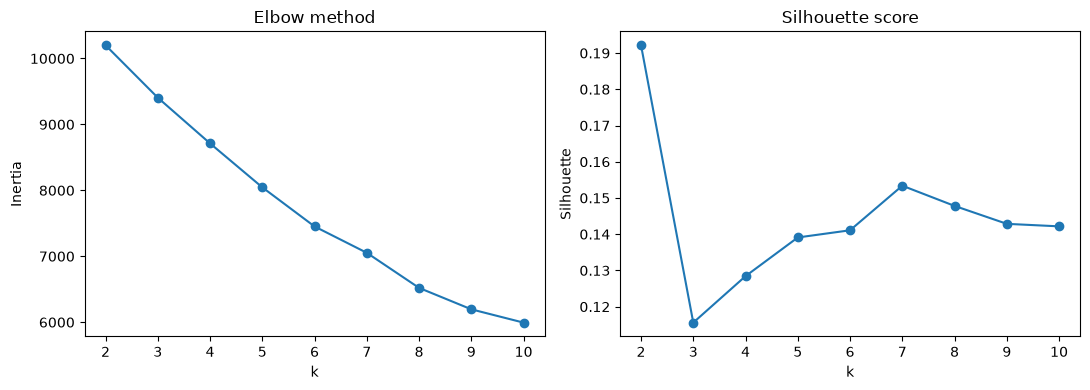

Using k = 2


In [13]:
audio_features = [
    "Time_Signature",
    "Danceability",
    "Energy",
    "Key",
    "Loudness",
    "Mode",
    "Speechiness",
    "Acousticness",
    "Instrumentalness",
    "Liveness",
    "Valence",
    "Tempo",
]
X = StandardScaler().fit_transform(df[audio_features])

k_range = range(2, 11)
inertias, sils = [], []
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X, km.labels_, sample_size=min(5000, len(X)), random_state=42))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(list(k_range), inertias, "o-"); ax[0].set(title="Elbow method", xlabel="k", ylabel="Inertia")
ax[1].plot(list(k_range), sils, "o-");     ax[1].set(title="Silhouette score", xlabel="k", ylabel="Silhouette")
plt.tight_layout(); plt.show()

K = None
if K is None:
    K = list(k_range)[int(np.argmax(sils))]
print(f"Using k = {K}")

In [14]:
kmeans = KMeans(n_clusters=K, n_init=20, random_state=42).fit(X)
df["Cluster"] = kmeans.labels_
print(f"Silhouette score: {silhouette_score(X, kmeans.labels_, sample_size=min(5000, len(X)), random_state=42):.3f}")
print("\nCluster sizes:\n", df["Cluster"].value_counts().sort_index())


Silhouette score: 0.192

Cluster sizes:
 Cluster
0    706
1    292
Name: count, dtype: int64


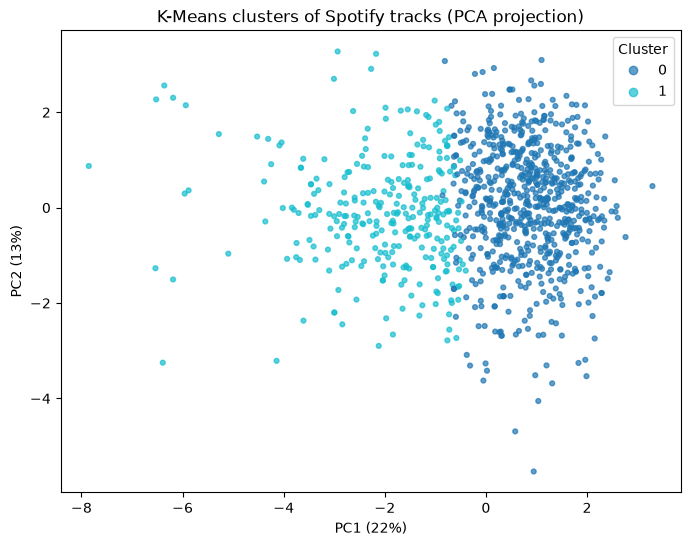

In [15]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X)
plt.figure(figsize=(8, 6))
sc = plt.scatter(coords[:, 0], coords[:, 1], c=df["Cluster"], cmap="tab10", s=12, alpha=0.7)
plt.legend(*sc.legend_elements(), title="Cluster")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%})")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%})")
plt.title("K-Means clusters of Spotify tracks (PCA projection)")
plt.show()



Cluster profiles (mean values):
          Time_Signature  Danceability  Energy    Key  Loudness   Mode  \
Cluster                                                                 
0                 3.993         0.667   0.725  5.300    -7.781  0.646   
1                 3.904         0.528   0.412  5.045   -11.558  0.795   

         Speechiness  Acousticness  Instrumentalness  Liveness  Valence  \
Cluster                                                                   
0              0.064         0.139             0.031     0.187    0.703   
1              0.041         0.500             0.071     0.158    0.361   

           Tempo  Popularity      Year  
Cluster                                 
0        122.026      58.788  1984.582  
1        118.192      55.219  1984.298  


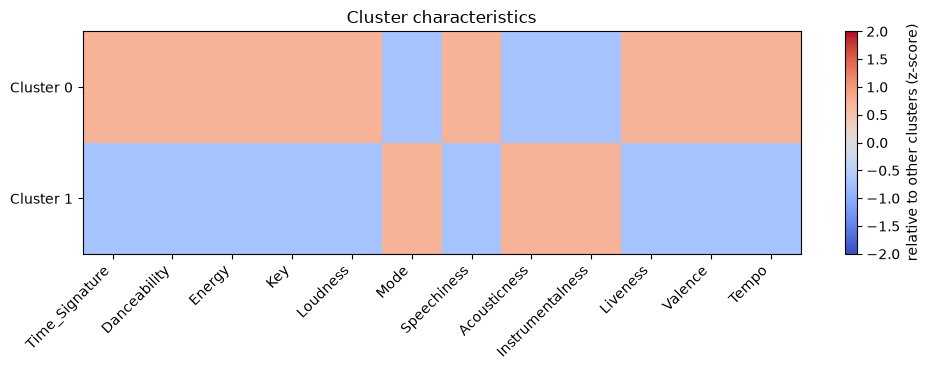


Cluster 0 - most typical tracks:
               Track                                        Artist  Year
              Xanadu Olivia Newton-John / Electric Light Orchestra  1980
    Smuggler’s Blues                                    Glenn Frey  1985
   When Smokey Sings                                           ABC  1987
Make Me Lose Control                                   Eric Carmen  1988
       Der Kommissar                                After the Fire  1983

Cluster 1 - most typical tracks:
                     Track               Artist  Year
Even The Nights Are Better           Air Supply  1982
                  Patience        Guns N’ Roses  1989
        The Search Is Over             Survivor  1985
                    Amanda               Boston  1986
          The Living Years Mike + The Mechanics  1989


In [18]:
#6. INTERPRET CLUSTERS

profile = df.groupby("Cluster")[audio_features + ["Popularity", "Year"]].mean().round(3)
print("\nCluster profiles (mean values):\n", profile)

# Heatmap of standardised means: what makes each cluster distinct
z = (profile[audio_features] - profile[audio_features].mean()) / profile[audio_features].std()
plt.figure(figsize=(10, 3 + 0.4 * K))
plt.imshow(z, cmap="coolwarm", aspect="auto", vmin=-2, vmax=2)
plt.xticks(range(len(audio_features)), audio_features, rotation=45, ha="right")
plt.yticks(range(K), [f"Cluster {i}" for i in range(K)])
plt.colorbar(label="relative to other clusters (z-score)")
plt.title("Cluster characteristics"); plt.tight_layout(); plt.show()

# Example tracks closest to each cluster centre
dist = kmeans.transform(X)
for c in range(K):
    idx = np.argsort(dist[:, c])[:5]
    print(f"\nCluster {c} - most typical tracks:")
    print(df.loc[idx, ["Track", "Artist", "Year"]].to_string(index=False))